In [15]:
%pip install numpy==2.2.0
%pip install collections
import os
import urllib.parse 
import requests
import holidays
import numpy as np
required_version = "2.2.0"
assert np.__version__ == required_version, f"Expected NumPy {required_version}, but got {np.__version__}"
import pandas as pd
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
import matplotlib.pyplot as plt
from collections import deque
import tqdm

# use already existent data if its available or query the database if it's not
if not os.path.exists("merged.csv"):

    # %% Define MySQL connection parameters
    db_user = "student"
    db_password = "#q6a21I&OA5k"
    host = "132.252.60.112"
    port = 3306
    dbname = "ENTSOE"

    #  %%Create MySQL engine
    engine = create_engine(
        f"mysql://{urllib.parse.quote_plus(db_user)}:{urllib.parse.quote_plus(db_password)}@{host}:{port}/{dbname}"
    )

    # %% Obtain specification table
    spec_query = "SELECT * FROM spec"
    spec = pd.read_sql_query(spec_query, engine)

    # Get an overview
    print(spec)
    spec.MapTypeCode.unique()
    spec.MapCode.unique()
    spec.Name.unique()
    spec.ProductionType.unique()
    spec.ResolutionCode.unique()
    spec.to_csv("spec.csv")

    # %% Get value by the production types, you can add more
    #  Narrow down the spec table to get the targetTimeSeriesID's
    targets = spec[
        (spec["Name"] == "Generation")
        & (spec["Type"].isin(["DayAhead", "Actual"]))
        & (spec["ProductionType"].isin(["Wind Onshore", "Wind Offshore", "Solar"]))
        & (spec["MapCode"] == "AT")  # Put desired BZN here
        & (spec["MapTypeCode"] == "BZN")
        ]

    # %% Obtain the forecasts table
    values_query = f"""
    SELECT *
    FROM vals
    WHERE TimeSeriesID IN ({", ".join(map(str, targets['TimeSeriesID']))})
    AND YEAR(`DateTime`) >= '2014'
    """
    values = pd.read_sql_query(values_query, engine)

    # %%

    # Get the actual data
    data = pd.merge(values, targets, on="TimeSeriesID")
    data = data[data["DateTime"].dt.year >= 2014]  # You can change the year here

    # Select and wrangle even further
    data = data[["DateTime", "Type", "ProductionType", "Value"]]
    data = data.sort_values(by="DateTime")
    data_generations = data.pivot_table(
        index="DateTime", columns=["Type", "ProductionType"], values="Value"
    )

    print(data_generations)
    data_generations.describe()
    data_generations.to_csv("data_generations.csv")

    # We have used the DE_LU BZN in the earlier example (data_generations).
    # You can get DE_AT_LU or any other zone data, such as FR, PT, and so on.
    # The DE_AT_LU zone was split into DE_LU and AT.
    # Please take a closer look at the specs.
    # To supplement further, you may follow the "R" codes.

    # ************************************************************************
    # %% Load data
    # *************************************************************************

    #  Narrow down the spec table to get the targetTimeSeriesID's
    targets = spec[
        (spec["Name"] == "Load")
        & (spec["Type"].isin(["DayAhead", "Actual"]))
        & (spec["MapCode"] == "AT")  # Put desired BZN here
        & (spec["MapTypeCode"] == "BZN")
        ]

    # %% Obtain the forecasts table
    values_query = f"""
    SELECT *
    FROM vals
    WHERE TimeSeriesID IN ({", ".join(map(str, targets['TimeSeriesID']))})
    AND YEAR(`DateTime`) >= '2014'
    """
    values = pd.read_sql_query(values_query, engine)

    # Get the actual data
    data = pd.merge(values, targets, on="TimeSeriesID")
    data = data[data["DateTime"].dt.year >= 2014]

    # Select and wrangle even further
    data = data[["DateTime", "Type", "Value"]]
    data = data.sort_values(by="DateTime")
    data_load = data.pivot_table(index="DateTime", columns=["Type"], values="Value")

    print(data_load)
    data_load.describe()
    data_load.to_csv("data_load.csv")

    # You can save the data to your desired directory, for further use

    # ************************************************************************
    # %% Priece data
    # *************************************************************************
    #  Narrow down the spec table to get the targetTimeSeriesID's
    targets = spec[
        (spec["Name"] == "Price")
        & (spec["Type"].isin(["DayAhead", "Actual"]))
        # & (spec["ProductionType"].isin(["Wind Onshore", "Wind Offshore", "Solar"]))
        & (spec["MapCode"] == "AT")  # Put desired price zones (BZN)here
        & (spec["MapTypeCode"] == "BZN")
        ]

    # %% Obtain the forecasts table
    values_query = f"""
    SELECT *
    FROM vals
    WHERE YEAR(`DateTime`) >= '2014'AND
    TimeSeriesID IN ({", ".join(map(str, targets['TimeSeriesID']))})"""

    values = pd.read_sql_query(values_query, engine)

    # Get the actual data
    data = pd.merge(values, targets, on="TimeSeriesID")
    data = data[data["DateTime"].dt.year >= 2014]

    # Select and wrangle even further
    data = data[["DateTime", "Type", "Value"]]
    data = data.sort_values(by="DateTime")
    data_price = data.pivot_table(index="DateTime", columns=["Type"], values="Value")

    print(data_price)
    data_price.describe()
    data_price.to_csv("data_price.csv")

    # Merge the dataframes
    # For data_generations (2 column levels: Type + ProductionType)
    # This flattens the MultiIndex columns by joining the two levels with an underscore
    data_generations.columns = ['_'.join(col).strip() for col in data_generations.columns.values]

    # for data_load (only typ as columnname)
    data_load.columns = [f'Load_{col}' for col in data_load.columns]

    # for data_price (only typ as columnname)
    data_price.columns = [f'Price_{col}' for col in data_price.columns]

    # Merge the dataframes on DateTime
    merged = (
        pd.merge(data_generations, data_load, on="DateTime", how="outer")
        .merge(data_price, on="DateTime", how="outer")
    )
    # print and save the data
    print(merged.info())
    print(merged.head())
    merged.to_csv("merged.csv")

else:
    merged = pd.read_csv("merged.csv", parse_dates=["DateTime"])
df = merged
#creature new feature based on the kind of day like workday
at_holidays = holidays.Austria()

df["target"] = df["Load_Actual"].shift(-1)

df["is_weekend"] = (df["DateTime"].dt.weekday >= 5).astype(int)
df["is_holiday"] = df["DateTime"].dt.date.map(at_holidays.__contains__).astype(int)
df["day_of_week"] = df["DateTime"].dt.weekday
df["week_of_year"] = df["DateTime"].dt.isocalendar().week.astype(int) - 1
df['is_workday'] = (~df['is_weekend'] & ~df['is_holiday']).astype(int)

seconds_in_day = 24 * 60 * 60
time_in_seconds = (
        df["DateTime"].dt.hour * 3600
        + df["DateTime"].dt.minute * 60
        + df["DateTime"].dt.second
)
df["time_sin"] = np.sin(2 * np.pi * time_in_seconds / seconds_in_day)
df["time_cos"] = np.cos(2 * np.pi * time_in_seconds / seconds_in_day)

dayahead_cols = df.filter(like="DayAhead").columns
df = df.drop(columns=dayahead_cols)

# delete row pre 1.10.2018
cutoff = pd.Timestamp("2018-10-01")
df = df[df["DateTime"] >= cutoff]

# delete all rows with NaNs
full_rows = ~df.isna().any(axis=1)
last_full_idx = full_rows[full_rows].index[-1]

# Alles danach verwerfen
df = df.loc[:last_full_idx]

# add lags features
df["load_lag_1"] = df["Load_Actual"].shift(1)
df["load_lag_2"] = df["Load_Actual"].shift(2)
df["load_lag_2"] = df["Load_Actual"].shift(3)
df["load_lag_4"] = df["Load_Actual"].shift(4)
df["load_lag_96"] = df["Load_Actual"].shift(96)
df["load_diff_1"] = df["load_lag_1"] - df["load_lag_2"]
df["load_diff_4"] = df["load_lag_1"] - df["load_lag_4"]
df["load_diff_24h"] = df["load_lag_1"] - df["load_lag_96"]

# rolling-statistics
df["load_mean_1h"] = df["Load_Actual"].rolling(4).mean()
df["load_std_1h"] = df["Load_Actual"].rolling(4).std()
df["load_ramp_1h"] = df["Load_Actual"].rolling(4).max() - df["Load_Actual"].rolling(4).min()

# cycling day ot the year
DOY = df['DateTime'].dt.dayofyear
angle = 2 * np.pi * DOY / 365
df['doy_sin'] = np.sin(angle)
df['doy_cos'] = np.cos(angle)

# delete NaNs after feature Engeneering
df = df.dropna().reset_index(drop=True)
# get start and end date for weather Data
start_date = df["DateTime"].min().date()
end_date = df["DateTime"].max().date()

# example: coordinates for Vienna
latitude = 48.2082
longitude = 16.3738

# query weather data via api
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date.isoformat(),
    "end_date": end_date.isoformat(),
    "hourly": "temperature_2m,shortwave_radiation,wind_speed_10m",
    "timezone": "auto"
}

response = requests.get(url, params=params)
data = response.json()

# weather dataframe
hourly_data = data.get("hourly", {})
weather = pd.DataFrame(hourly_data)

# time column in datetime
if "time" in weather.columns:
    weather["time"] = pd.to_datetime(weather["time"])

# format and sort datatime
df = df.sort_values("DateTime")
weather = weather.sort_values("time")

# merge on datetime (left join: df ← weather)
df = pd.merge_asof(df, weather, left_on="DateTime", right_on="time", direction="backward")

# drop weather time
df = df.drop(columns=["time"])

# Parameter for the curvature strength
p = 1.2  # 1 = linear, >1 = stronger increase at extreme values

# Heating demand: stronger increase below 15 °C
df["heating_demand"] = df["temperature_2m"].apply(lambda t: (15 - t) ** p if t < 15 else 0)

# Cooling demand: stronger increase above 22 °C
df["cooling_demand"] = df["temperature_2m"].apply(lambda t: (t - 22) ** p if t > 22 else 0)

print(df)

drop_cols = {"Load_Actual", "target", "Actual_Solar", "Actual_Wind Onshore"}
num_bool  = df.select_dtypes(include=["number", "bool"]).columns
FEATS     = sorted([c for c in num_bool if c not in drop_cols])




Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement collections (from versions: none)
ERROR: No matching distribution found for collections


                  DateTime  Actual_Solar  Actual_Wind Onshore  Load_Actual  \
0      2018-10-02 00:00:00           0.0                570.0       5724.4   
1      2018-10-02 00:15:00           0.0                580.0       5720.8   
2      2018-10-02 00:30:00           0.0                624.0       5674.8   
3      2018-10-02 00:45:00           0.0                632.0       5670.8   
4      2018-10-02 01:00:00           0.0                660.0       5708.0   
...                    ...           ...                  ...          ...   
233096 2025-05-26 02:00:00           0.0                130.0       4963.6   
233097 2025-05-26 02:15:00           0.0                124.0       5018.8   
233098 2025-05-26 02:30:00           0.0                132.0       5074.4   
233099 2025-05-26 02:45:00           0.0                136.0       5207.2   
233100 2025-05-26 03:00:00           0.0                134.0       5428.8   

        target  is_weekend  is_holiday  day_of_week  week_of_ye

In [16]:
# baseline model: Linear Regression as comparison
features = df.drop(columns=["DateTime", "target"])
target = df["target"]

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)

print(f"Linear Regression MAE: {mae:.2f}")
print(f"Linear Regression RMSE: {rmse:.2f}")

Linear Regression MAE: 42.88
Linear Regression RMSE: 3663.22


C:\Users\Julian Gaming\AppData\Local\Temp\ipykernel_20532\1800409200.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"target_t+{i}"] = df["Load_Actual"].shift(-i)
C:\Users\Julian Gaming\AppData\Local\Temp\ipykernel_20532\1800409200.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"target_t+{i}"] = df["Load_Actual"].shift(-i)
C:\Users\Julian Gaming\AppData\Local\Temp\ipykernel_20532\1800409200.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times,

Average RMSE across 96 forecast steps: 738.41
             datetime  forecast_load
0 2025-05-25 03:15:00    4664.800000
1 2025-05-25 03:30:00    4705.967919
2 2025-05-25 03:45:00    4755.869128
3 2025-05-25 04:00:00    4815.450206
4 2025-05-25 04:15:00    4884.169223


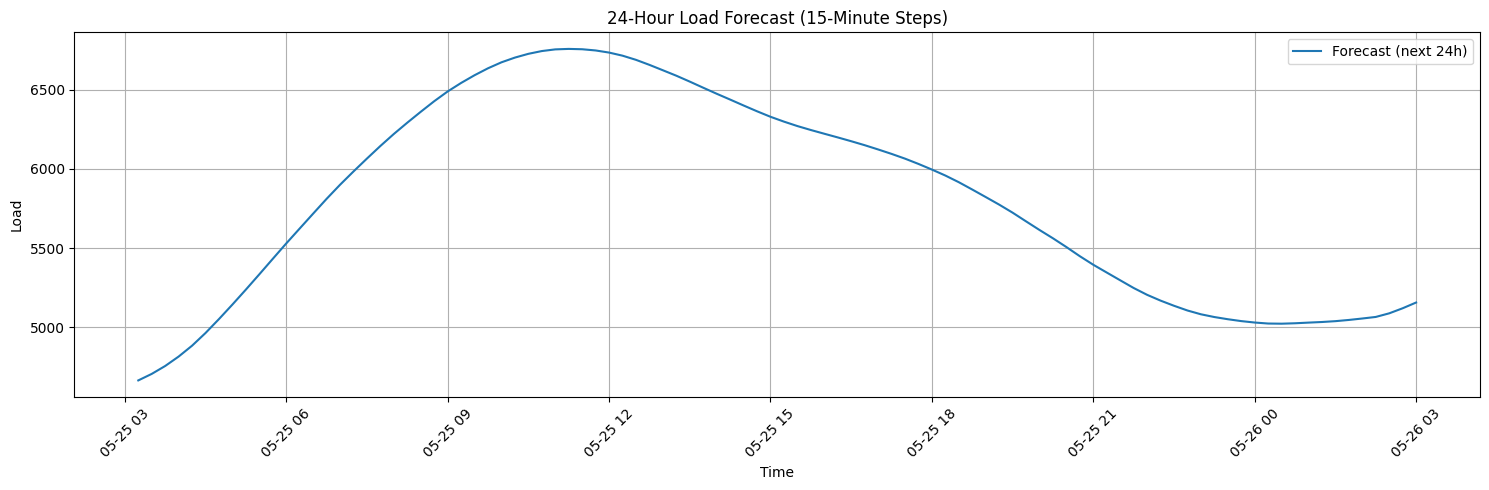

In [17]:
# Forecast horizon: 96 steps (24 hours with 15-minute intervals)
n_steps = 96

# Create target columns: t+1 to t+96
for i in range(1, n_steps + 1):
    df[f"target_t+{i}"] = df["Load_Actual"].shift(-i)

# Drop rows with missing target values
df_model = df.dropna(subset=[f"target_t+{i}" for i in range(1, n_steps + 1)])

# Define feature and target columns
exclude_cols = ["DateTime", "Load_Actual"] + [f"target_t+{i}" for i in range(1, n_steps + 1)]
feature_cols = [col for col in df_model.columns if col not in exclude_cols]
target_cols = [f"target_t+{i}" for i in range(1, n_steps + 1)]

X = df_model[feature_cols]
y = df_model[target_cols]

# Time-series-aware train-test split (no shuffling!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Multi-output LinearRegression model
base_model = LinearRegression()
model = MultiOutputRegressor(base_model)
model.fit(X_train, y_train)

# Prediction and RMSE evaluation
y_pred = model.predict(X_test)
rmse_per_step = np.sqrt(np.mean((y_pred - y_test.values) ** 2, axis=0))
rmse_avg = np.mean(rmse_per_step)

print("Average RMSE across 96 forecast steps:", round(rmse_avg, 2))

# Example forecast for the next 24 hours (from the last point in the dataset)
latest_X = df_model[feature_cols].iloc[[-1]]
forecast = model.predict(latest_X).flatten()

# Generate timestamps for the next 96 steps
forecast_times = pd.date_range(
    start=df_model["DateTime"].iloc[-1] + pd.Timedelta(minutes=15),
    periods=96, freq="15min"
)

forecast_df = pd.DataFrame({
    "datetime": forecast_times,
    "forecast_load": forecast
})

print(forecast_df.head())

# Optional: plot the forecast
plt.figure(figsize=(15, 5))
plt.plot(forecast_df["datetime"], forecast_df["forecast_load"], label="Forecast (next 24h)")
plt.title("24-Hour Load Forecast (15-Minute Steps)")
plt.xlabel("Time")
plt.ylabel("Load")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# recursive 96-step forcast function

ALPHA = 2 / (96 + 1)

def add_fourier(idx15, row):
    for k in (1, 2, 3):
        row[f"day_sin{k}"], row[f"day_cos{k}"] = (
            np.sin(2*np.pi*k*idx15/96),  np.cos(2*np.pi*k*idx15/96)
        )
    for k in (1, 2):
        row[f"week_sin{k}"], row[f"week_cos{k}"] = (
            np.sin(2*np.pi*k*idx15/672), np.cos(2*np.pi*k*idx15/672)
        )

def rec_forecast(mdl, base_row, H=96):
    """Walk the model forward H steps (24 h) with real-time feature updates."""
    hist = deque(df["Load_Actual"].iloc[max(0, base_row.name-672+1):base_row.name+1],
                 maxlen=672)
    cur  = base_row.copy()
    ema  = cur["ema_24h"]
    preds = []

    for _ in range(H):
        # advance 15 minutes
        dt = cur["DateTime"] + pd.Timedelta(minutes=15)
        cur["DateTime"] = dt

        # calendar flags
        dow  = dt.weekday()
        cur["day_of_week"]  = dow
        cur["week_of_year"] = dt.isocalendar().week - 1
        cur["is_weekend"]   = int(dow >= 5)
        cur["is_holiday"]   = int(AT.__contains__(dt.date()))
        cur["is_workday"]   = int(not cur["is_weekend"] and not cur["is_holiday"])

        # intraday seasonality
        sec = dt.hour*3600 + dt.minute*60
        cur["time_sin"], cur["time_cos"] = (
            np.sin(2*np.pi*sec/86400), np.cos(2*np.pi*sec/86400)
        )

        # annual seasonality
        ang = 2*np.pi*dt.timetuple().tm_yday/365
        cur["doy_sin"], cur["doy_cos"] = np.sin(ang), np.cos(ang)

        # Fourier time indices
        idx15 = int((dt - T0) / pd.Timedelta(minutes=15))
        for k in (1, 2, 3):
            cur[f"day_sin{k}"], cur[f"day_cos{k}"] = (
                np.sin(2*np.pi*k*idx15/96),  np.cos(2*np.pi*k*idx15/96)
            )
        for k in (1, 2):
            cur[f"week_sin{k}"], cur[f"week_cos{k}"] = (
                np.sin(2*np.pi*k*idx15/672), np.cos(2*np.pi*k*idx15/672)
            )

        # lagged loads
        for lag in (1, 2, 3, 4, 96, 192, 672):
            cur[f"load_lag_{lag}"] = hist[-lag] if len(hist) >= lag else hist[0]

        # deltas
        cur["load_diff_1"]    = cur["load_lag_1"] - cur["load_lag_2"]
        cur["load_diff_4"]    = cur["load_lag_1"] - cur["load_lag_4"]
        cur["load_diff_24h"]  = cur["load_lag_1"] - cur["load_lag_96"]
        cur["load_diff_week"] = cur["load_lag_1"] - cur["load_lag_672"]

        # rolling statistics
        for w, t in ((4, "1h"), (24, "6h"), (96, "24h"), (672, "1w")):
            seg = list(hist)[-w:] if len(hist) >= w else list(hist)
            cur[f"load_mean_{t}"], cur[f"load_std_{t}"], cur[f"load_ramp_{t}"] = (
                np.mean(seg), np.std(seg, ddof=0), max(seg) - min(seg)
            )

        # exponential moving average
        ema = ALPHA * hist[-1] + (1 - ALPHA) * ema
        cur["ema_24h"] = ema

        # final feature vector
        X = cur.reindex(FEATS).to_frame().T.astype(float).fillna(0)
        y_hat = mdl.predict(X)[0]

        preds.append(y_hat)
        hist.append(y_hat)
        cur["Load_Actual"] = y_hat

    return np.array(preds)


# evaluation
y_pred = pd.DataFrame(model.predict(X_test),
                      columns=target_cols,
                      index=y_test.index)

# error per forecast horizon
rmse_h = np.sqrt(((y_test - y_pred) ** 2).mean())
mape_h = (np.abs((y_test - y_pred) / y_test).mean()) * 100

print("Mean MAPE across all forecast steps: {:.2f}%".format(mape_h.mean()))
print("Mean RMSE across all forecast steps: {:.2f} kW".format(rmse_h.mean()))

global linearregressionmodel_rmse
global linearregressionmodel_mape

linearregressionmodel_rmse = rmse_h
linearregressionmodel_mape = mape_h



Mean MAPE across all forecast steps: 8.89%
Mean RMSE across all forecast steps: 738.41 kW
target_t+1     4.753489e-14
target_t+2     8.006089e-01
target_t+3     1.534290e+00
target_t+4     2.271430e+00
target_t+5     3.016968e+00
                   ...     
target_t+92    7.810458e+00
target_t+93    7.765358e+00
target_t+94    7.721246e+00
target_t+95    7.684097e+00
target_t+96    7.660792e+00
Length: 96, dtype: float64


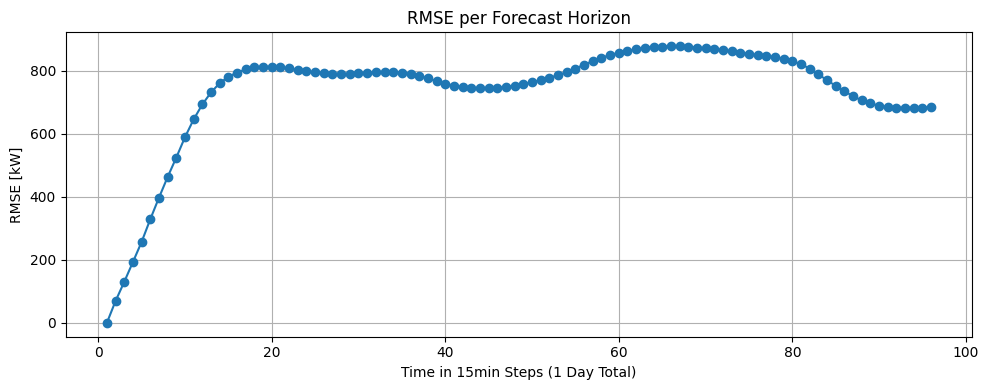

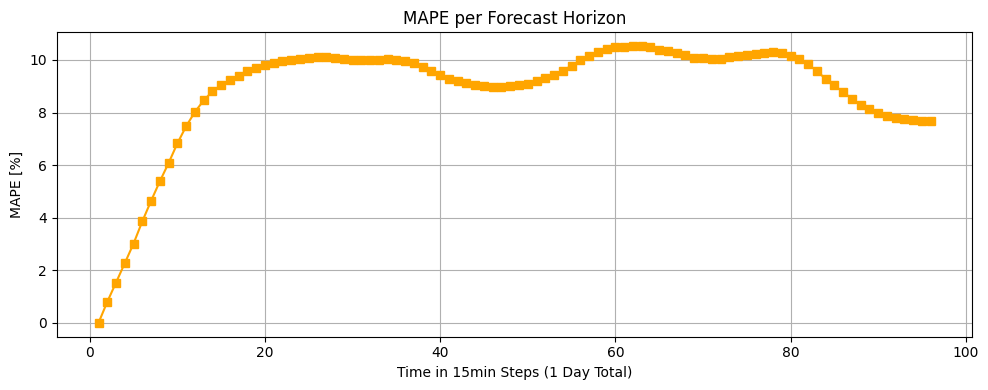

In [24]:

# MAPE & RMSE per forecast horizon
rmse_h = np.sqrt(((y_test - y_pred) ** 2).mean())
mape_h = (np.abs((y_test - y_pred) / y_test).mean()) * 100

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(rmse_h)+1), rmse_h, label="RMSE [kW]", marker="o")
plt.ylabel("RMSE [kW]")
plt.xlabel("Time in 15min Steps (1 Day Total)")
plt.grid(True)
plt.title("RMSE per Forecast Horizon")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(mape_h)+1), mape_h, label="MAPE [%]", marker="s", color="orange")
plt.ylabel("MAPE [%]")
plt.xlabel("Time in 15min Steps (1 Day Total)")
plt.grid(True)
plt.title("MAPE per Forecast Horizon")
plt.tight_layout()
plt.show()